In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, TimeSeriesSplit, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
DROP_COLS = [
    # Identifiers (not predictive)
    'game_id', 'season', 'home_team', 'away_team', 
    'home_team_abbrev', 'away_team_abbrev', 'matchup',
    
    # Target variable
    # 'home_win',
    # 'date'
    
    # Game outcome stats (only known AFTER the game - data leakage)
    'home_gf', 'away_gf', 'home_ga', 'away_ga', 'home_sog', 'away_sog',
    'home_faceoffwin_pct', 'away_faceoffwin_pct',
    'home_powerplays', 'away_powerplays', 'home_powerplay_pct', 'away_powerplay_pct',
    'home_pk', 'away_pk', 'home_pk_pct', 'away_pk_pct',
    'home_pims', 'away_pims', 'home_hits', 'away_hits',
    'home_blockedshots', 'away_blockedshots', 'home_takeaways', 'away_takeaways',
    'home_giveaways', 'away_giveaways',
    
    # Goalie stats from THIS game
    'home_save_pct', 'away_save_pct',
    'home_goalie_save_pct', 'away_goalie_save_pct',
    'home_goalie_ga', 'away_goalie_ga',
    'home_goalie_saves', 'away_goalie_saves',
    'home_goalie_evenStrengthShotsAgainst', 'away_goalie_evenStrengthShotsAgainst',
    'home_goalie_powerPlayShotsAgainst', 'away_goalie_powerPlayShotsAgainst',
    'home_goalie_shorthandedShotsAgainst', 'away_goalie_shorthandedShotsAgainst',
    'home_goalie_evenStrengthGoalsAgainst', 'away_goalie_evenStrengthGoalsAgainst',
    'home_goalie_powerPlayGoalsAgainst', 'away_goalie_powerPlayGoalsAgainst',
]


In [3]:
# list all of the columns
# temp_df = pd.read_csv("../scripts/generated/data/nhl_data.csv")

# print("All columns in the dataset: ", temp_df.columns.tolist())

In [4]:
HOME_TEAM_L5_COLS = [
    'home_gf_ewm', 'home_ga_ewm', 'home_sog_ewm',
    'home_wins_l5', 'home_win_pct_l5', 'home_powerplay_pct_ewm',
    'home_penalty_kill_pct_ewm', 'home_powerplays_l5', 'home_penalty_kills_l5',
    'home_faceoffwin_pct_ewm', 'home_pims_ewm', 'home_hits_ewm',
    'home_blockedshots_ewm', 'home_giveaways_ewm', 'home_takeaways_ewm',
]

AWAY_TEAM_L5_COLS = [
    'away_gf_ewm', 'away_ga_ewm', 'away_sog_ewm',
    'away_wins_l5', 'away_win_pct_l5', 'away_powerplay_pct_ewm',
    'away_penalty_kill_pct_ewm', 'away_powerplays_l5', 'away_penalty_kills_l5',
    'away_faceoffwin_pct_ewm', 'away_pims_ewm', 'away_hits_ewm',
    'away_blockedshots_ewm', 'away_giveaways_ewm', 'away_takeaways_ewm',
]

GOALIE_L5_COLS = [
    'home_goalie_save_pct_ewm', 'home_goalie_ga_ewm', 'home_goalie_saves_ewm',
    'home_goalie_ev_sa_ewm', 'home_goalie_pp_sa_ewm', 'home_goalie_sh_sa_ewm',
    'home_goalie_ev_ga_ewm', 'home_goalie_pp_ga_ewm', 
    'away_goalie_save_pct_ewm', 'away_goalie_ga_ewm', 'away_goalie_saves_ewm',
    'away_goalie_ev_sa_ewm', 'away_goalie_pp_sa_ewm', 'away_goalie_sh_sa_ewm',
    'away_goalie_ev_ga_ewm', 'away_goalie_pp_ga_ewm',
]

TEAM_GOALIE_PERFORMANCE = [
    'home_team_save_pct_ewm', 'away_team_save_pct_ewm',
]

SEASON_COLS = [
    'home_win_pct_season', 'away_win_pct_season',
    'home_home_win_pct', 'away_away_win_pct',
    'home_gf_per_game_season', 'away_gf_per_game_season',
    'home_pointPctg_season', 'away_pointPctg_season', 'pointPctg_diff',
]

DIFF_COLS = [
    'home_goal_diff_ewm', 'home_ga_diff_ewm', 'home_shot_diff_ewm',
]

STREAKS_AND_REST = [
    'home_win_streak', 'away_win_streak',
    'home_rest_days', 'away_rest_days',
    'home_goalie_rest_days', 'away_goalie_rest_days',
]

HEAD_TO_HEAD = [
    'home_h2h_wins', 'home_h2h_gf', 'away_h2h_wins', 
    'away_h2h_gf', 'home_h2h_wins_diff',
]

FEATURE_COLS = (
    HOME_TEAM_L5_COLS +
    AWAY_TEAM_L5_COLS +
    GOALIE_L5_COLS +
    TEAM_GOALIE_PERFORMANCE +
    SEASON_COLS +
    DIFF_COLS +
    STREAKS_AND_REST +
    HEAD_TO_HEAD
)


In [5]:
# =============================================================================
# 3. EXPLORE DATA
# =============================================================================

# Load data - UPDATE THIS PATH
filepath = "../scripts/generated/data/nhl_data.csv"
df = pd.read_csv(filepath)

print(f"\nDataset shape: {df.shape}")
print(f"Columns in dataset: {len(df.columns)}")
print(f"Date range: {df['date'].min()} to {df['date'].max()}")

# Check target distribution
print("\n" + "="*60)
print("TARGET VARIABLE DISTRIBUTION")
print("="*60)
print(df['home_win'].value_counts())
print(f"\nHome win percentage: {df['home_win'].mean():.2%}")


Dataset shape: (3936, 128)
Columns in dataset: 128
Date range: 2023-10-10 to 2026-04-16

TARGET VARIABLE DISTRIBUTION
home_win
1    2133
0    1803
Name: count, dtype: int64

Home win percentage: 54.19%


In [6]:
# =============================================================================
# 4. PREPARE FEATURES
# =============================================================================

# Check which features are available
available_features = [col for col in FEATURE_COLS if col in df.columns]
missing_features = [col for col in FEATURE_COLS if col not in df.columns]

print("\n" + "="*60)
print("FEATURE AVAILABILITY")
print("="*60)
print(f"Available features: {len(available_features)}/{len(FEATURE_COLS)}")

if missing_features:
    print(f"\nMissing features ({len(missing_features)}):")
    for feat in missing_features[:10]:
        print(f"  - {feat}")
    if len(missing_features) > 10:
        print(f"  ... and {len(missing_features) - 10} more")

# Prepare features and target
X = df[available_features].copy()
y = df['home_win'].copy()

# Keep date for splitting
dates = pd.to_datetime(df['date'])

print(f"\nFeatures shape: {X.shape}")
print(f"Target shape: {y.shape}")

# Check missing values
missing_counts = X.isnull().sum()
if missing_counts.sum() > 0:
    print(f"\nMissing values per feature:")
    print(missing_counts[missing_counts > 0])

# Handle missing values
print(f"\nMissing values before imputation: {X.isnull().sum().sum()}")

# X = X.dropna()

# # Fill with median
# X = X.fillna(X.median())

# # Handle any infinite values
# X = X.replace([np.inf, -np.inf], np.nan)
# X = X.fillna(X.median())

print(f"Missing values after imputation: {X.isnull().sum().sum()}")


FEATURE AVAILABILITY
Available features: 71/71

Features shape: (3936, 71)
Target shape: (3936,)

Missing values per feature:
home_goalie_save_pct_ewm    11
home_goalie_ga_ewm          11
home_goalie_saves_ewm       11
home_goalie_ev_sa_ewm       11
home_goalie_pp_sa_ewm       11
home_goalie_sh_sa_ewm       11
home_goalie_ev_ga_ewm       11
home_goalie_pp_ga_ewm       11
away_goalie_save_pct_ewm    27
away_goalie_ga_ewm          27
away_goalie_saves_ewm       27
away_goalie_ev_sa_ewm       27
away_goalie_pp_sa_ewm       27
away_goalie_sh_sa_ewm       27
away_goalie_ev_ga_ewm       27
away_goalie_pp_ga_ewm       27
home_goalie_rest_days       44
away_goalie_rest_days       64
dtype: int64

Missing values before imputation: 412
Missing values after imputation: 412


In [7]:
# shape
print(f"\nFinal features shape: {X.shape}")
print(f"Final target shape: {y.shape}")


Final features shape: (3936, 71)
Final target shape: (3936,)


In [8]:
# =============================================================================
# 5. EXPANDING WINDOW TIME-SERIES BACKTEST
# =============================================================================

print("\n" + "="*60)
print("TIME-BASED DATA SPLIT")
print("="*60)

non_missing_idx = X.dropna().index

# Filter first
X_clean = X.loc[non_missing_idx]
y_clean = y.loc[non_missing_idx]
dates_clean = dates.loc[non_missing_idx]

# Sort by date
sorted_idx = dates_clean.sort_values().index

X_sorted = X_clean.loc[sorted_idx].reset_index(drop=True)
y_sorted = y_clean.loc[sorted_idx].reset_index(drop=True)
dates_sorted = dates_clean.loc[sorted_idx].reset_index(drop=True)

n = len(X_sorted)

# Expanding window parameters
initial_train_size = int(n * 0.6)
step_size = int(n * 0.1)

accuracies = []
fold = 1

start_train = initial_train_size

# Expanding window loop
while start_train + step_size <= n:

    test_end = min(start_train + step_size, n)

    # Expanding training window
    X_train = X_sorted[:start_train]
    y_train = y_sorted[:start_train]

    # Next chunk as test (NO overlap)
    X_test = X_sorted[start_train:test_end]
    y_test = y_sorted[start_train:test_end]

    # Safety check
    if len(X_test) == 0:
        break

    # Train model
    model = RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)

    print(f"\nFold {fold}")
    print(f"Train: {dates_sorted.iloc[0].date()} → "
          f"{dates_sorted.iloc[start_train - 1].date()} "
          f"({len(X_train)} games)")
    print(f"Test:  {dates_sorted.iloc[start_train].date()} → "
          f"{dates_sorted.iloc[test_end - 1].date()} "
          f"({len(X_test)} games)")
    print(f"Accuracy: {acc:.4f}")

    # Expand window
    start_train = test_end
    fold += 1

# 5. Final summary
print("\n" + "="*60)
print("FINAL RESULTS")
print(f"accuracies: {accuracies}")
print("="*60)
print(f"Average Expanding Window Accuracy: {np.mean(accuracies):.4f}")
print(f"Std Dev Across Folds: {np.std(accuracies):.4f}")


TIME-BASED DATA SPLIT

Fold 1
Train: 2023-10-10 → 2025-03-15 (2298 games)
Test:  2025-03-15 → 2025-10-26 (383 games)
Accuracy: 0.7441

Fold 2
Train: 2023-10-10 → 2025-10-26 (2681 games)
Test:  2025-10-27 → 2025-12-18 (383 games)
Accuracy: 0.6423

Fold 3
Train: 2023-10-10 → 2025-12-18 (3064 games)
Test:  2025-12-18 → 2026-02-26 (383 games)
Accuracy: 0.6658

Fold 4
Train: 2023-10-10 → 2026-02-26 (3447 games)
Test:  2026-02-26 → 2026-04-16 (383 games)
Accuracy: 0.6423

FINAL RESULTS
accuracies: [0.7441253263707572, 0.6422976501305483, 0.6657963446475196, 0.6422976501305483]
Average Expanding Window Accuracy: 0.6736
Std Dev Across Folds: 0.0418


In [9]:
# # =============================================================================
# # 6. BASELINE MODEL
# # =============================================================================

# print("\n" + "="*60)
# print("BASELINE MODEL (Default Parameters)")
# print("="*60)

# # Train baseline model
# base_rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
# base_rf_model.fit(X_train, y_train)

# # Evaluate on validation set
# y_val_pred = base_rf_model.predict(X_val)
# baseline_acc = accuracy_score(y_val, y_val_pred)

# print(f"\nBaseline Validation Accuracy: {baseline_acc:.4f}")

In [10]:
# =============================================================================
# 7. HYPERPARAMETER TUNING
# =============================================================================

print("\n" + "="*60)
print("HYPERPARAMETER TUNING")
print("="*60)

# 1. Create chronological train / val / test split
n = len(X_sorted)

train_end = int(n * 0.6)
val_end = int(n * 0.8)

X_train = X_sorted[:train_end]
y_train = y_sorted[:train_end]

X_val = X_sorted[train_end:val_end]
y_val = y_sorted[train_end:val_end]

X_test = X_sorted[val_end:]
y_test = y_sorted[val_end:]

print(f"Train size: {len(X_train)}")
print(f"Val size:   {len(X_val)}")
print(f"Test size:  {len(X_test)}")

# Combine train + val for tuning
X_train_val = pd.concat([X_train, X_val]).reset_index(drop=True)
y_train_val = pd.concat([y_train, y_val]).reset_index(drop=True)

# 2. Define parameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
}

print("\nTotal combinations:",
      len(param_grid['n_estimators']) *
      len(param_grid['max_depth']) *
      len(param_grid['min_samples_split']) *
      len(param_grid['min_samples_leaf']))

# 3. TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=5)

rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=tscv,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2
)

print("\nRunning grid search...\n")

grid_search.fit(X_train_val, y_train_val)

# 4. Best hyperparameters
print("\n" + "="*60)
print("BEST HYPERPARAMETERS")
print("="*60)

for param, value in grid_search.best_params_.items():
    print(f"{param}: {value}")

print(f"\nBest Cross Validation Accuracy: {grid_search.best_score_:.4f}")

# 5. Retrain on FULL train+val
best_model = grid_search.best_estimator_
best_model.fit(X_train_val, y_train_val)


HYPERPARAMETER TUNING
Train size: 2298
Val size:   766
Test size:  766

Total combinations: 36

Running grid search...

Fitting 5 folds for each of 36 candidates, totalling 180 fits

BEST HYPERPARAMETERS
max_depth: 10
min_samples_leaf: 1
min_samples_split: 5
n_estimators: 300

Best Cross Validation Accuracy: 0.6831


RandomForestClassifier(max_depth=10, min_samples_split=5, n_estimators=300,
                       n_jobs=-1, random_state=42)

In [11]:
# =============================================================================
# 8. MODEL EVALUATION ON TEST SET
# =============================================================================

print("\n" + "="*60)
print("TEST SET PERFORMANCE")
print("="*60)

# Use the tuned model trained on full train+val
y_test_pred = best_model.predict(X_test)

# Compute accuracy
test_accuracy = accuracy_score(y_test, y_test_pred)

# Optional: additional metrics
from sklearn.metrics import classification_report, confusion_matrix

print(f"Test Accuracy: {test_accuracy:.4f}\n")

print("Classification Report:")
print(classification_report(y_test, y_test_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_test_pred))


TEST SET PERFORMANCE
Test Accuracy: 0.6540

Classification Report:
              precision    recall  f1-score   support

           0       0.66      0.56      0.61       365
           1       0.65      0.74      0.69       401

    accuracy                           0.65       766
   macro avg       0.66      0.65      0.65       766
weighted avg       0.66      0.65      0.65       766

Confusion Matrix:
[[204 161]
 [104 297]]



FEATURE IMPORTANCE ANALYSIS


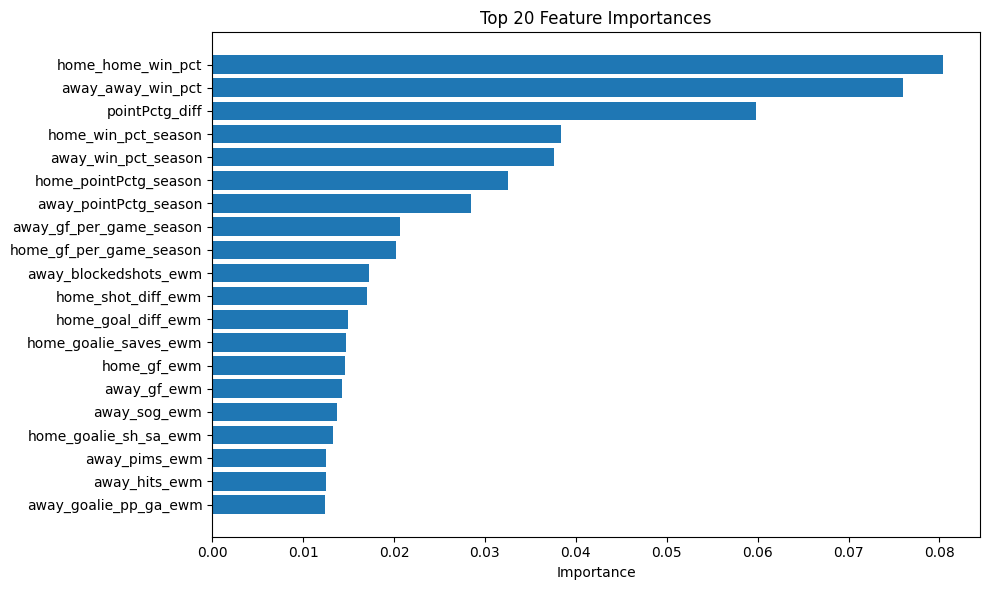

In [12]:
# =============================================================================
# FEATURE IMPORTANCE ANALYSIS
# =============================================================================

print("\n" + "="*60)
print("FEATURE IMPORTANCE ANALYSIS")
print("="*60)

# Build dataframe
fi = pd.DataFrame({
    "feature": available_features,
    "importance": best_model.feature_importances_
}).sort_values("importance", ascending=False).head(20)

# Plot
plt.figure(figsize=(10, 6))
plt.barh(fi["feature"][::-1], fi["importance"][::-1])
plt.title("Top 20 Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()



CREATING VISUALIZATIONS


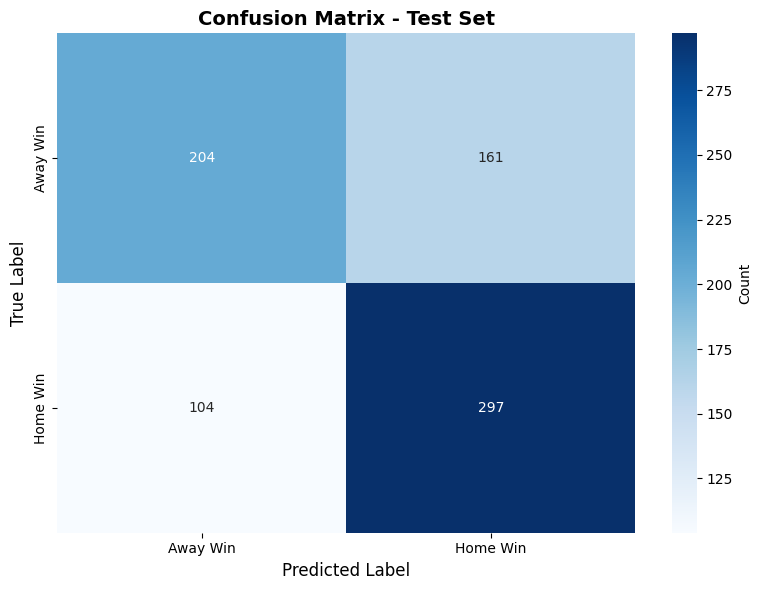

In [13]:
# =============================================================================
# 9. VISUALIZATIONS
# =============================================================================

print("\n" + "="*60)
print("CREATING VISUALIZATIONS")
print("="*60)

cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Away Win', 'Home Win'],
    yticklabels=['Away Win', 'Home Win'],
    cbar_kws={'label': 'Count'}
)
plt.title('Confusion Matrix - Test Set', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()
plt.close()

In [14]:
# =============================================================================
# 10. FINAL SUMMARY
# =============================================================================

print("\n" + "="*60)
print("FINAL MODEL SUMMARY")
print("="*60)
print(f"\nModel: Random Forest Classifier")
print(f"Features: {len(available_features)}")
print(f"\nData Split (Time-based):")
print(f"  Train:      {len(X_train)} games")
print(f"  Validation: {len(X_val)} games")
print(f"  Test:       {len(X_test)} games")
print(f"\nBest Hyperparameters:")
for param, value in grid_search.best_params_.items():
    print(f"  {param}: {value}")
print(f"\nTest Set Performance:")
print(f"  Accuracy:  {test_accuracy:.4f}")
print("\n" + "="*60)
print("COMPLETE!")
print("="*60)


FINAL MODEL SUMMARY

Model: Random Forest Classifier
Features: 71

Data Split (Time-based):
  Train:      2298 games
  Validation: 766 games
  Test:       766 games

Best Hyperparameters:
  max_depth: 10
  min_samples_leaf: 1
  min_samples_split: 5
  n_estimators: 300

Test Set Performance:
  Accuracy:  0.6540

COMPLETE!


In [15]:
# =============================================================================
# 11. SAVE MODEL
# =============================================================================

import pickle

with open('./models/nhl_rf_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

with open('./models/feature_names.pkl', 'wb') as f:
    pickle.dump(available_features, f)

print("\nModel saved: nhl_rf_model.pkl")
print("Features saved: feature_names.pkl")


Model saved: nhl_rf_model.pkl
Features saved: feature_names.pkl
